# KNN
O código abaixo carrega o dataset MNIST, que consiste em imagens de dígitos entre $0$ e $9$ e carrego a classe com o algoritmo do KNN

## Algoritmo
Seja $\mathcal{D} := {(x_1, y_1), \ldots, (x_N, y_N)} \subset \mathcal{X} \times \mathcal{Y}$ o conjunto de treinamento e $d : \mathcal{D} \times \mathcal{D} \to \mathbb{R}^{+} \cup {0}$ uma função de distância.

Vamos supor que queremos classificar um vetor $x \in \mathcal{X}$ arbitrário.

O método k-NN classifica o vetor $x$ atribuindo a ele a classe mais comum entre os rótulos dos pontos em $\mathcal{V}_k(x)$, ou seja:

$$
h(x)
=
\operatorname{argmax}_{y \in \mathcal{Y}}
\sum_{(x_i, y_i) \in \mathcal{V}_k(x)}
\mathbb{I}\{y_i = y\}
$$
Seja $\mathcal{D} := \{(x_1, y_1), ..., (x_N, y_N)\} \subset \mathcal{X} \times \mathcal{Y}$ o conjunto de treinamento e $d: \mathcal{D} \times \mathcal{D} \rightarrow \mathbb{R}^+ \cup \{0\}$ uma função de *distância*. Vamos supor que queremos classificar um vetor $x \in \mathcal{X}$ arbitrário. 

O método k-NN classifica o vetor $x$ atribuindo a ele a classe mais comum entre os rótulos dos pontos em $\mathcal{V}_k (x)$, ou seja:
$$
  h(x) := \text{argmax}_{y \in \mathcal{Y}} \sum_{(x_i, y_i) \in \mathcal{V}_k (x)} \mathbb{I}\{y_i = y\}
$$

## Configuração e Dados

In [4]:
import matplotlib.pyplot as plt
from types import SimpleNamespace
from torchvision.datasets import MNIST
import sys
from pathlib import Path
import torch

root = Path().resolve().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
train_dataset = MNIST(root=str(root / '..' / 'data'), train=True, download=False)
test_dataset = MNIST(root=str(root / '..' / 'data'), train=False, download=False)

mnist = SimpleNamespace(
    features_train=train_dataset.data.view(len(train_dataset), -1).to(device=device, dtype=torch.float32),
    labels_train=train_dataset.targets.to(device=device),
    features_test=test_dataset.data.view(len(test_dataset), -1).to(device=device, dtype=torch.float32),
    labels_test=test_dataset.targets.to(device=device),
)

## Treino

Agora eu faço uma procura pela melhor quantidade de amostras para considerar durante o treion ($k$)

In [6]:
ks = torch.tensor([3, 4, 5], device=device)
max_k = int(ks.max().item())
batch_size = 256


def knn_predict_batch(features_train: torch.Tensor, labels_train: torch.Tensor, query_batch: torch.Tensor, k_values: torch.Tensor) -> torch.Tensor:
    distances = torch.cdist(query_batch, features_train)
    _, indices = torch.topk(distances, k=max_k, largest=False)
    nearest_labels = labels_train[indices]

    batch_predictions = []
    for k in k_values.tolist():
        batch_predictions.append(torch.mode(nearest_labels[:, :k], dim=1).values)

    return torch.stack(batch_predictions, dim=0)


predictions = []

print(f"Predicting MNIST test set in batches of {batch_size} with ks={ks.tolist()}...")
for start in range(0, len(mnist.features_test), batch_size):
    end = min(start + batch_size, len(mnist.features_test))
    query_batch = mnist.features_test[start:end]
    batch_predictions = knn_predict_batch(mnist.features_train, mnist.labels_train, query_batch, ks)
    predictions.append(batch_predictions)

predictions = torch.cat(predictions, dim=1)
print(f"Done. Prediction tensor shape: {tuple(predictions.shape)}")

Predicting MNIST test set in batches of 256 with ks=[3, 4, 5]...
Done. Prediction tensor shape: (3, 10000)


Agora vou calcular a precisão das predições e selecionar o melhor $k$ (Há outras métricas interessantes também, mas manterei simples)

In [7]:
accuracies = torch.zeros((len(ks),), device=device)
for idx, k in enumerate(ks):
    correct_predictions = (predictions[idx] == mnist.labels_test).sum()
    accuracies[idx] = correct_predictions.float() / len(mnist.labels_test)


In [8]:
print("KNN Accuracies:")
for idx, k in enumerate(ks):
    print(f"K={k.item()}: {accuracies[idx].item():.4f}")


KNN Accuracies:
K=3: 0.9705
K=4: 0.9682
K=5: 0.9686


Agora, para uma visualização interessante, mostramos as amostras que foram classificadas incorretamente

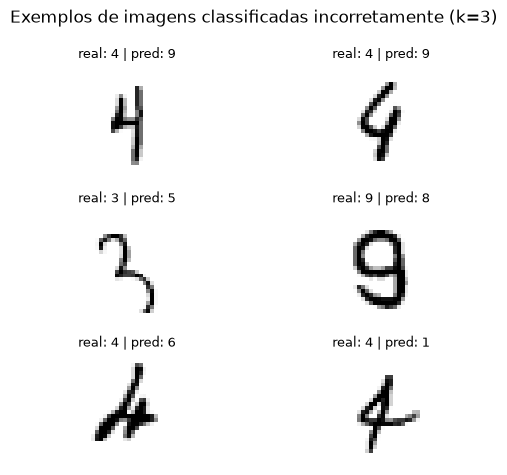

In [9]:
# Amostras classificadas incorretamente:
visualized_k = 0
missclassified_mask = predictions[visualized_k] != mnist.labels_test
missclassified_indices = torch.where(missclassified_mask)[0]

# Exibir algumas amostras classificadas incorretamente (NumPy só para plot)
n_to_show = min(6, len(missclassified_indices))
fig, axes = plt.subplots(3, 2)
axes = axes.ravel()

for i in range(n_to_show):
    idx_test = missclassified_indices[i].item()
    axes[i].imshow(
        mnist.features_test[idx_test].detach().cpu().numpy().reshape(28, 28),
        cmap="gray_r",
    )
    axes[i].set_title(
        f"real: {mnist.labels_test[idx_test].item()} | pred: {int(predictions[visualized_k][idx_test].item())}",
        fontsize=9,
    )
    axes[i].axis("off")

for i in range(n_to_show, len(axes)):
    axes[i].axis("off")

plt.suptitle(f"Exemplos de imagens classificadas incorretamente (k={ks[visualized_k].item()})")
plt.tight_layout()
plt.show()

E até que da pra entender o porquê o algoritmo classifica elas errado, elas estão muito "mal escritas" vamos dizer assim, lembrando bastante outros números